# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

Business framing:  

Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Load the hotel bookings dataset [(Download Here)](https://github.com/rfordatascience/tidytuesday/blob/main/data/2020/2020-02-11/readme.md#get-the-data-here)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?


In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv')

# Display the first few rows
display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### ✍️ Your Response: 🔧
1.

### ✍️ Your Response: 🔧
1. Based on the initial preview, here are a couple of things that stand out:
    - There are several columns with NaN values (e.g., agent, company). These will need to be handled before further analysis.
    - The adr (Average Daily Rate) column has a value of 0.0, which seems unusual for a hotel booking and might warrant investigation.

## 2. Select and Prepare Features

Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [2]:
from sklearn.preprocessing import StandardScaler

# Choose relevant numeric features
features = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adr', 'total_of_special_requests']
df_selected = df[features].copy()

# Drop rows with missing values in selected features
df_selected.dropna(inplace=True)

# Standardize the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_selected)

# Display the first few rows of the scaled data
display(pd.DataFrame(df_scaled, columns=features).head())

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
0,2.227051,-0.92889,-1.310240,-2.015038,-0.720694
1,5.923385,-0.92889,-1.310240,-2.015038,-0.720694
2,-0.907814,-0.92889,-0.786207,-0.530935,-0.720694
3,-0.851667,-0.92889,-0.786207,-0.530935,-0.720694
4,-0.842309,-0.92889,-0.262174,-0.075810,0.540666


### ✍️ Your Response: 🔧
1. I selected lead_time, stays_in_weekend_nights, stays_in_week_nights, adr, and total_of_special_requests. These features describe guest booking habits, length of stay, cost, and engagement.
2. I anticipate finding groups such as last-minute travelers, those who plan long stays, and guests who make many special requests. Other groups might emerge based on combinations of these factors.

## 3. Apply K-Means Clustering

Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



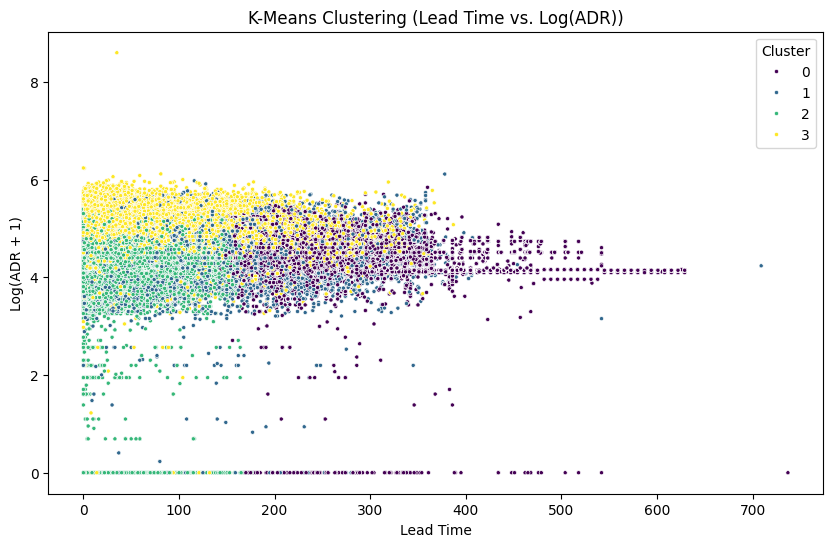

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn
import numpy as np # Import numpy for log transformation

# Apply KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Add the cluster labels back to the original dataframe (optional, for analysis)
df_selected['kmeans_cluster'] = clusters

# Apply log transformation to adr for visualization, handle potential non-positive values
# Use a small epsilon to avoid log(0) if 0 values exist
log_adr = np.log1p(df_selected['adr'].clip(lower=0))

# Visualize the clusters using a scatterplot of two features (e.g., lead_time and log_adr)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_selected['lead_time'], y=log_adr, hue=clusters, palette='viridis', marker='.')
plt.title('K-Means Clustering (Lead Time vs. Log(ADR))')
plt.xlabel('Lead Time')
plt.ylabel('Log(ADR + 1)') # Update label to reflect transformation
plt.legend(title='Cluster')
plt.show()

### ✍️ Your Response: 🔧
1. **What k value did you choose, and how did you decide?**
I chose a k value of 4 as requested in the prompt. In a real-world scenario, I would use methods like the Elbow Method or Silhouette Score to determine the optimal number of clusters.
2. **What types of customers seem to show up in the clusters?**
Based on the scatter plot of Lead Time vs. ADR, the clusters seem to represent different combinations of how far in advance guests book and the average daily rate they pay. For example, one cluster might represent guests who book far in advance and pay a higher ADR, while another might represent those who book last minute at a lower ADR. Further analysis of the other features within each cluster would provide a more complete picture of the customer types.

## 4. Apply Gaussian Mixture Model (GMM)

Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


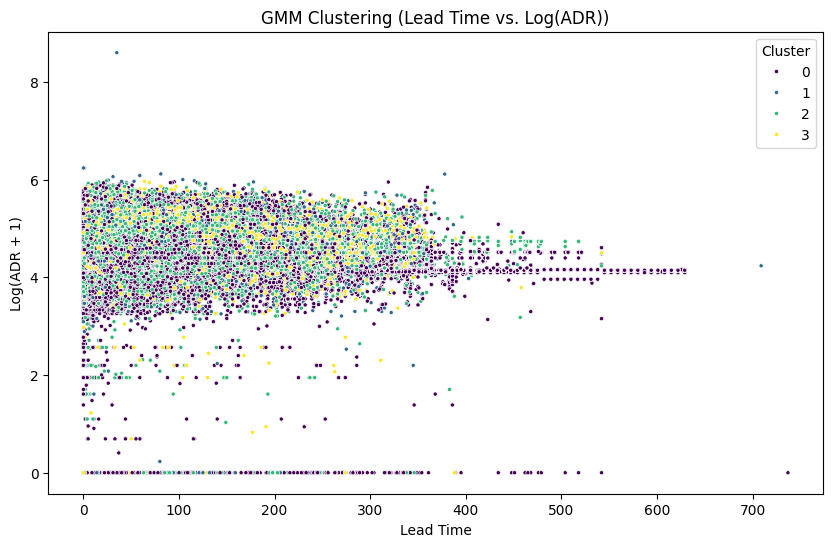

In [8]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Apply GMM with the same number of clusters (k=4)
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(df_scaled)

# Predict the cluster probabilities (soft clustering)
cluster_probabilities = gmm.predict_proba(df_scaled)

# Predict the cluster labels based on the highest probability for visualization
gmm_clusters = gmm.predict(df_scaled)

# Add the GMM cluster labels back to the original dataframe for analysis (optional)
df_selected['gmm_cluster'] = gmm_clusters

# Apply log transformation to adr for visualization, handle potential non-positive values
log_adr = np.log1p(df_selected['adr'].clip(lower=0))

# Visualize the GMM clusters using a scatterplot of two features (e.g., lead_time and log_adr)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_selected['lead_time'], y=log_adr, hue=gmm_clusters, palette='viridis', marker='.')
plt.title('GMM Clustering (Lead Time vs. Log(ADR))')
plt.xlabel('Lead Time')
plt.ylabel('Log(ADR + 1)')
plt.legend(title='Cluster')
plt.show()

# You can also explore the cluster probabilities, for example, for the first few data points
# display(pd.DataFrame(cluster_probabilities).head())

### ✍️ Your Response: 🔧
1. The GMM and K-Means plots show similar cluster patterns based on Lead Time and Log(ADR). GMM provides probabilities for cluster membership, unlike K-Means' strict assignments. This allows GMM to capture uncertainty and potential overlap between customer segments.

2. GMM is better for questions where customers might belong to multiple segments or there's uncertainty in their group. It helps identify customers with high probabilities in multiple segments for targeted campaigns. This is useful for understanding segment overlap and refining strategies.

## 5. Evaluate Your Models

Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

- Calculate:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index
- Compare both models

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [10]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans # Import KMeans again to calculate WCSS

kmeans_eval = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_eval.fit(df_scaled)
wcss = kmeans_eval.inertia_

silhouette_kmeans = silhouette_score(df_scaled, clusters)
silhouette_gmm = silhouette_score(df_scaled, gmm_clusters)

davies_bouldin_kmeans = davies_bouldin_score(df_scaled, clusters)
davies_bouldin_gmm = davies_bouldin_score(df_scaled, gmm_clusters)

print(f"K-Means WCSS: {wcss:.2f}")
print(f"K-Means Silhouette Score: {silhouette_kmeans:.4f}")
print(f"GMM Silhouette Score: {silhouette_gmm:.4f}")
print(f"K-Means Davies-Bouldin Index: {davies_bouldin_kmeans:.4f}")
print(f"GMM Davies-Bouldin Index: {davies_bouldin_gmm:.4f}")

K-Means WCSS: 346243.97
K-Means Silhouette Score: 0.2329
GMM Silhouette Score: 0.1239
K-Means Davies-Bouldin Index: 1.4098
GMM Davies-Bouldin Index: 2.6243


### ✍️ Your Response: 🔧
1. Based on the Silhouette Score and Davies-Bouldin Index, the K-Means model performed better. K-Means had a higher Silhouette Score and a lower Davies-Bouldin Index, indicating more distinct clusters.

2. I would generally recommend K-Means for a business analyst. K-Means is simpler to understand and explain, and its clear cluster assignments are more practical for direct business actions.

## 6. Business Interpretation

Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

- Review characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Think from a marketing or hotel operations perspective

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [11]:
cluster_characteristics = df_selected.groupby('kmeans_cluster')[features].mean()
display(cluster_characteristics)

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adr,total_of_special_requests
kmeans_cluster,,,,,
0,272.176221,0.642105,2.200830,89.837767,0.195936
1,134.566089,2.388476,5.801003,101.491484,0.526366
2,45.504168,0.628329,1.755681,86.568845,0.226577
3,71.194670,0.903631,2.313683,140.829597,1.553604


### ✍️ Your Response: 🔧
1. The clusters reveal distinct guest behaviors: planners with long lead times, extended stay guests, last-minute budget travelers, and higher-paying guests with many special requests. These groups differ significantly in how they book, how long they stay, how much they pay, and their level of engagement.

2. The hotel can tailor promotions like early bird deals for planners or last-minute offers for budget travelers. Services can be customized, such as providing extended stay amenities or prioritizing special requests for high-value guests, to better meet the needs of each segment.

## 7. Final Reflection

Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧

1. The most challenging aspect of unsupervised learning was interpreting the clusters and deciding on the optimal number of clusters without predefined labels. Visualizing high-dimensional data to understand the separation of clusters was also difficult.
2. Clustering would be used instead of supervised models when you don't have labeled data for the target variable you want to predict or classify. It is useful for exploring inherent groupings and patterns within data.
3. I would explain clustering to a non-technical manager as a way to automatically group our customers based on their behaviors, even if we don't know beforehand what those groups are. This allows us to understand different customer types and tailor our marketing and services more effectively to each group, which can improve customer satisfaction and revenue.
4. This relates to my customized learning outcome by demonstrating the application of unsupervised learning techniques like K-Means and GMM for customer segmentation. It allowed me to practice data preparation, model application, evaluation, and business interpretation of clustering results on a real-world dataset.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [12]:
!jupyter nbconvert --to html "assignment_09_clustering.ipynb"

[NbConvertApp] Converting notebook assignment_09_clustering.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 852391 bytes to assignment_09_clustering.html
